In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import gget
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
import scipy
from scipy.stats import pearsonr
from scipy.spatial.distance import cdist
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm


from scipy.spatial.distance import pdist, squareform
from collections import defaultdict

sc.settings.verbosity = 2

# Load in processed anndata

In [2]:
%%time
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups.h5ad"
adata = sc.read_h5ad(path)

adata.uns['phase_colors'] = ['#ad3803', '#56b567', 'gold']

sc.logging.print_memory_usage()
adata

Memory usage: current 2.37 GB, difference +2.37 GB
CPU times: user 359 ms, sys: 2.25 s, total: 2.61 s
Wall time: 6.61 s


/home/jrcwycy/miniconda3/envs/rapids/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


AnnData object with n_obs × n_vars = 15950 × 25042
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_variable', 'highly_variable_rank', 'means', 'variance

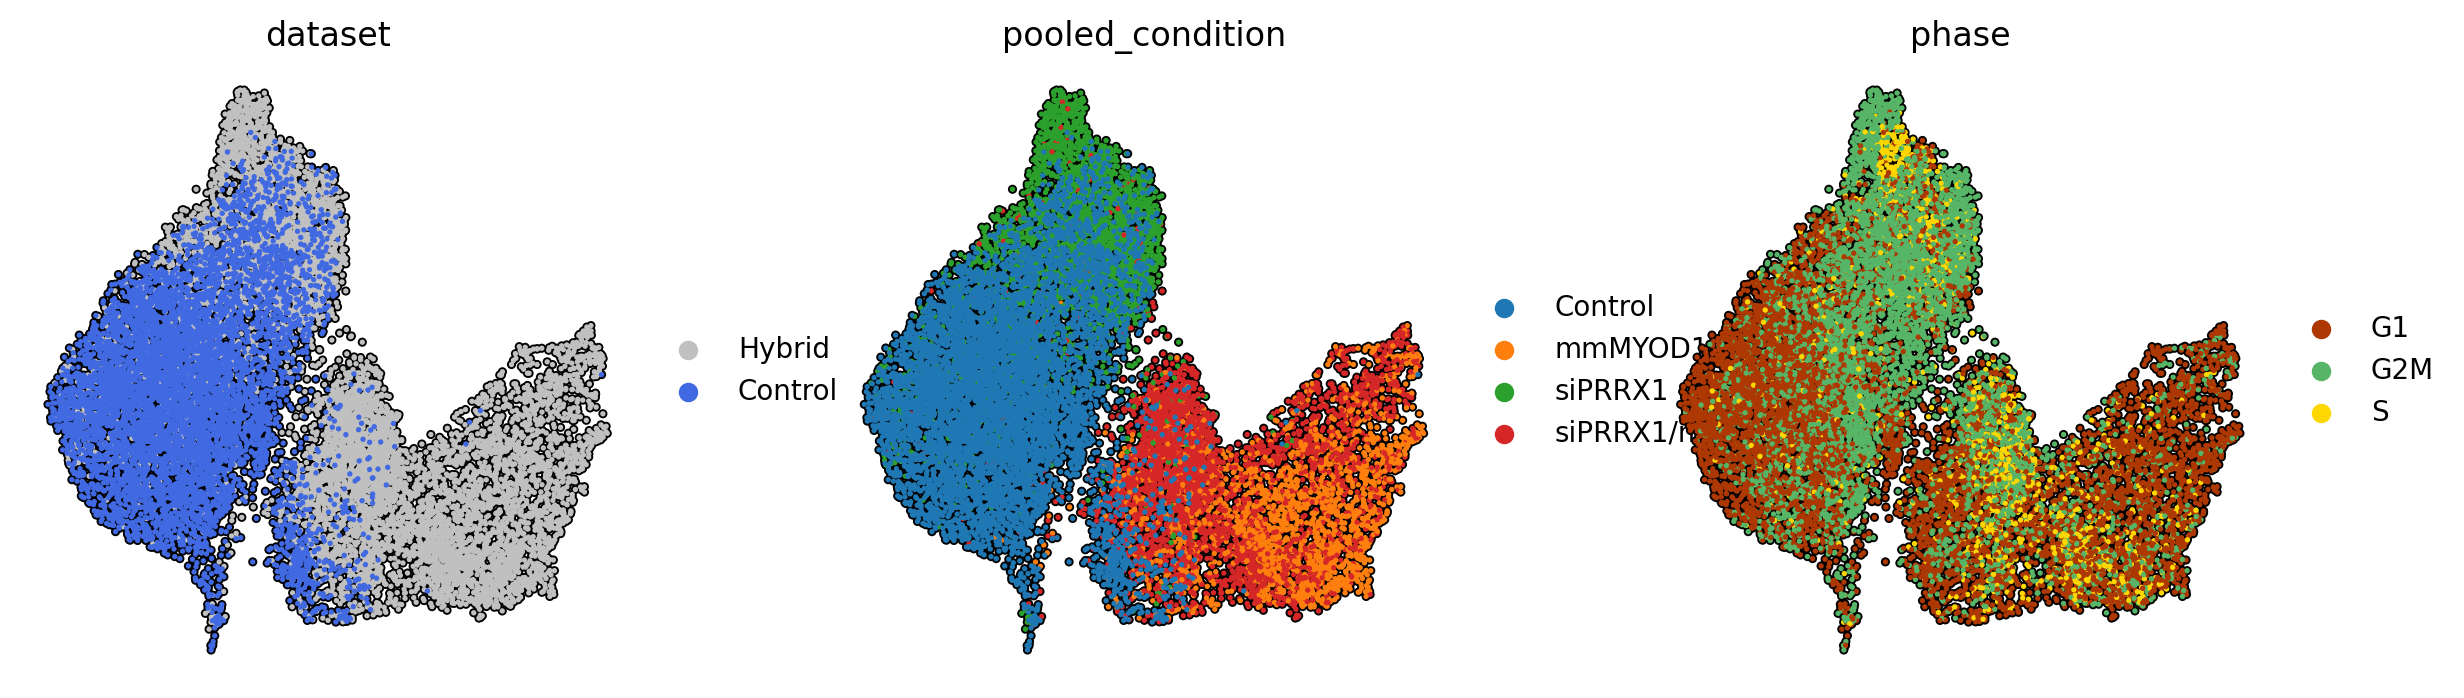

In [3]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    color=['dataset', 'pooled_condition', 'phase'],
    size=15,
    ncols=3,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
)

# DGE

mmMYOD1, siPRRX1, siPRRX1/mmMYOD1, Controls

In [14]:
def get_significant_DEGs(df, alpha=0.05, logfc_thresh=0.5, pct_nz_thresh=0.0):
    
    """ Filters DGE results for significant differentially expressed genes. 
    
    Params
    ------
        df (pd.DataFrame): Dataframe containing DGE results.
        alpha (float): Adjusted p-value threshold for statistical significance. Genes below this threshold are considered significant.
        logfc_thresh (float): Minimum absolute logfoldchange required for a gene to be considered significantly DE. 
        pct_nz_thresh (float): Minimum proportion of cells in the group of interest expressing the gene. Genes expressed in fewer cells than this threshold will be excluded.
    
    """
    
    tmp = df.copy()
    
    print(f"Filtering for significant DEGs (adjusted p-value < {alpha}, logfoldchange > {logfc_thresh})...")

    tmp['abs_lfc'] = tmp['logfoldchanges'].apply('abs')
    tmp = tmp[(tmp['abs_lfc'] > logfc_thresh) & (tmp['pvals_adj'] < alpha)]
    
    # tmp = tmp[(tmp['pct_nz_group'] > pct_nz_thresh) | (tmp['pct_nz_reference'] > pct_nz_thresh)]
    
    if pct_nz_thresh != 0.0:
        # tmp = tmp[(tmp['pct_nz_group'] > pct_nz_thresh) | (tmp['pct_nz_reference'] > pct_nz_thresh)]
        tmp = tmp[tmp['pct_nz_group'] > pct_nz_thresh]# | (tmp['pct_nz_reference'] > pct_nz_thresh)]
        print(f"Removed genes expressed in less than {pct_nz_thresh*100}% of cells.")
    
    print(f"N unique significant DEGs: {tmp['names'].nunique()}\n")
    
    return tmp

In [4]:
# all groups vs each other
sc.tl.rank_genes_groups(
    adata, 
    groupby="pooled_condition",
    method='wilcoxon',
    corr_method='benjamini-hochberg',
    use_raw=False,
    layer='log_norm',
    pts=True,
    key_added='each_vs_rest',
)

# hyb groups vs controls
sc.tl.rank_genes_groups(
    adata, 
    groupby="pooled_condition",
    reference='Control',
    method='wilcoxon',
    corr_method='benjamini-hochberg',
    use_raw=False,
    layer='log_norm',
    pts=True,
    key_added='condition_vs_control',
)

ranking genes
    finished (0:00:43)
ranking genes
    finished (0:01:10)


In [15]:
deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    key='condition_vs_control',
)

sig = get_significant_DEGs(deg, pct_nz_thresh=0.2)
sig.head()

Filtering for significant DEGs (adjusted p-value < 0.05, logfoldchange > 0.5)...
Removed genes expressed in less than 20.0% of cells.
N unique significant DEGs: 5237



,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,abs_lfc
0,mmMYOD1,MYOD1,69.678673,32.184513,0.0,0.0,1.000000,32.184513
1,mmMYOD1,MT-ND4,69.559166,2.778089,0.0,0.0,0.999526,2.778089
2,mmMYOD1,LINC-PINT,59.171329,2.708041,0.0,0.0,0.970128,2.708041
3,mmMYOD1,NAV3,58.639927,3.446840,0.0,0.0,0.924609,3.446840
4,mmMYOD1,TAF1D,55.636890,2.705306,0.0,0.0,0.960645,2.705306


In [16]:
gdf = adata.var[['gene_type', 'mt', 'ribo']].copy()
gdf = gdf.reset_index(names='names')

pdf = pd.merge(sig, gdf, how='left', on='names')

print("Removing non protein-coding, unnamed, and mitochondrial genes...\n")

pdf = pdf[pdf['gene_type'] == 'protein_coding'] # get only protein-coding genes
pdf = pdf[~pdf['names'].str.startswith(('ENSG', 'MT-'))] # remove unnamed and MT genes
# pdf = pdf[~pdf['ribo']] # remove ribosomal genes

print(f"N unique DE protein-coding genes: {pdf['names'].nunique()}\n")

for i in pdf['group'].unique():
    tmp = pdf[pdf['group'] == i]
    print(f"N upregulated genes for {i}: {tmp[tmp['logfoldchanges'] > 0]['names'].nunique()}")
    print(f"N downregulated genes for {i}: {tmp[tmp['logfoldchanges'] < 0]['names'].nunique()}\n")

pdf.head()

Removing non protein-coding, unnamed, and mitochondrial genes...

N unique DE protein-coding genes: 4904

N upregulated genes for mmMYOD1: 2727
N downregulated genes for mmMYOD1: 1054

N upregulated genes for siPRRX1: 2208
N downregulated genes for siPRRX1: 471

N upregulated genes for siPRRX1/mmMYOD1: 2206
N downregulated genes for siPRRX1/mmMYOD1: 724



,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,abs_lfc,gene_type,mt,ribo
0,mmMYOD1,MYOD1,69.678673,32.184513,0.0,0.0,1.000000,32.184513,protein_coding,False,False
3,mmMYOD1,NAV3,58.639927,3.446840,0.0,0.0,0.924609,3.446840,protein_coding,False,False
4,mmMYOD1,TAF1D,55.636890,2.705306,0.0,0.0,0.960645,2.705306,protein_coding,False,False
5,mmMYOD1,KCNQ5,54.305904,2.960109,0.0,0.0,0.952584,2.960109,protein_coding,False,False
6,mmMYOD1,IFIT3,52.313427,1.631886,0.0,0.0,0.984353,1.631886,protein_coding,False,False


In [17]:
pdf.sort_values(by=['group', 'logfoldchanges'], ascending=[True, False]).head()

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,abs_lfc,gene_type,mt,ribo
0,mmMYOD1,MYOD1,69.678673,32.184513,0.000000e+00,0.000000e+00,1.000000,32.184513,protein_coding,False,False
905,mmMYOD1,TAS2R19,15.551889,11.040074,1.544808e-54,2.222003e-53,0.223329,11.040074,protein_coding,False,False
632,mmMYOD1,CHRNA1,18.197309,9.463173,5.420632e-74,1.049022e-72,0.261735,9.463173,protein_coding,False,False
316,mmMYOD1,TAS2R30,23.689327,9.032257,4.645199e-124,1.510715e-122,0.340920,9.032257,protein_coding,False,False
48,mmMYOD1,ESR1,38.310966,8.280114,0.000000e+00,0.000000e+00,0.552394,8.280114,protein_coding,False,False


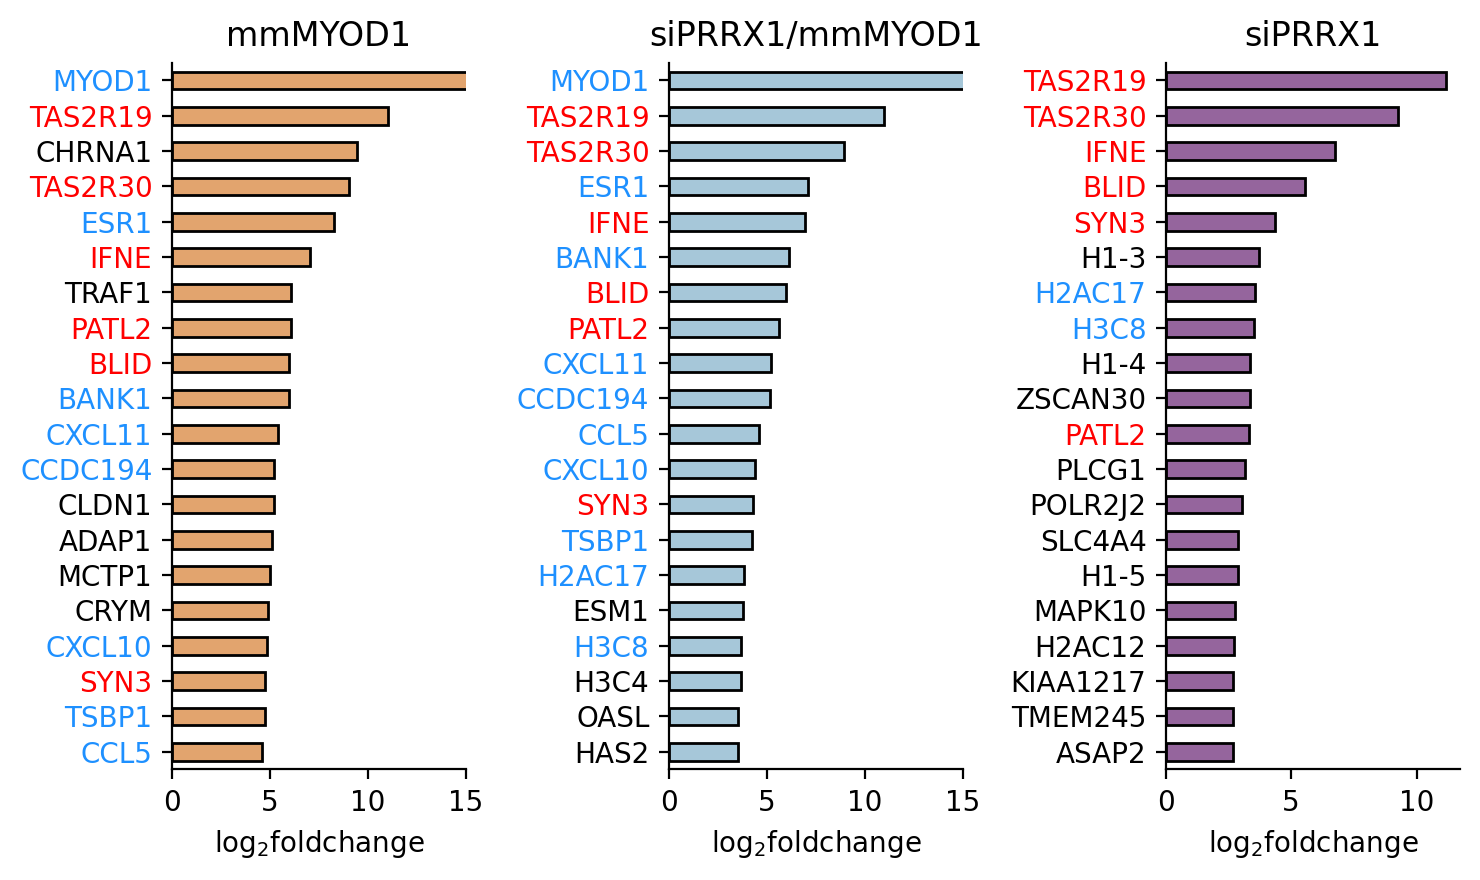

In [19]:
from collections import Counter

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 7.5, 4.5

fig, axs = plt.subplots(nrows=1, ncols=3)

n_genes = 20

top_genes_per_group = {}

plot_order = ["mmMYOD1", "siPRRX1/mmMYOD1", "siPRRX1"]
color_map = {
    "siPRRX1": "#9B5CA6",
    "siPRRX1/mmMYOD1": "#9ECAE1",
    "mmMYOD1": "#F5A35B",
    "Control": "silver"
}

for group in plot_order:
    df = pdf[pdf['group'] == group].sort_values(by='logfoldchanges', ascending=False)
    top_genes_per_group[group] = df.head(n_genes)['names'].tolist()

# Step 2: Count appearances across groups
gene_counts = Counter()
for gene_list in top_genes_per_group.values():
    gene_counts.update(gene_list)

# Step 3: Categorize genes
red_genes = {gene for gene, count in gene_counts.items() if count == 3}
blue_genes = {gene for gene, count in gene_counts.items() if count == 2}

for i, group in enumerate(plot_order): 
    df = pdf[pdf['group'] == group].sort_values(by='logfoldchanges', ascending=False).head(n_genes)
    ax = axs[i]

    sns.barplot(data=df, x='logfoldchanges', y='names', ax=ax, width=0.5, color=color_map[group], ec='k')
    ax.set_title(group)
    ax.set_xlabel("log$_2$foldchange")
    ax.set_ylabel("")

    if group == 'mmMYOD1':
        ax.set_xlim([0, 15])
        # ax.set_xscale('log')
    elif group == 'siPRRX1/mmMYOD1':
        ax.set_xlim([0, 15])
        # ax.set_xscale('log')
    # else:
    #     ax.set_xlim([0, 5])

    for tick in ax.get_yticklabels():
        gene = tick.get_text()
        if gene in red_genes:
            tick.set_color('red')
            # tick.set_fontweight('semibold')
        elif gene in blue_genes:
            tick.set_color('dodgerblue')
            # tick.set_fontweight('semibold')

sns.despine()
plt.tight_layout()
plt.show()

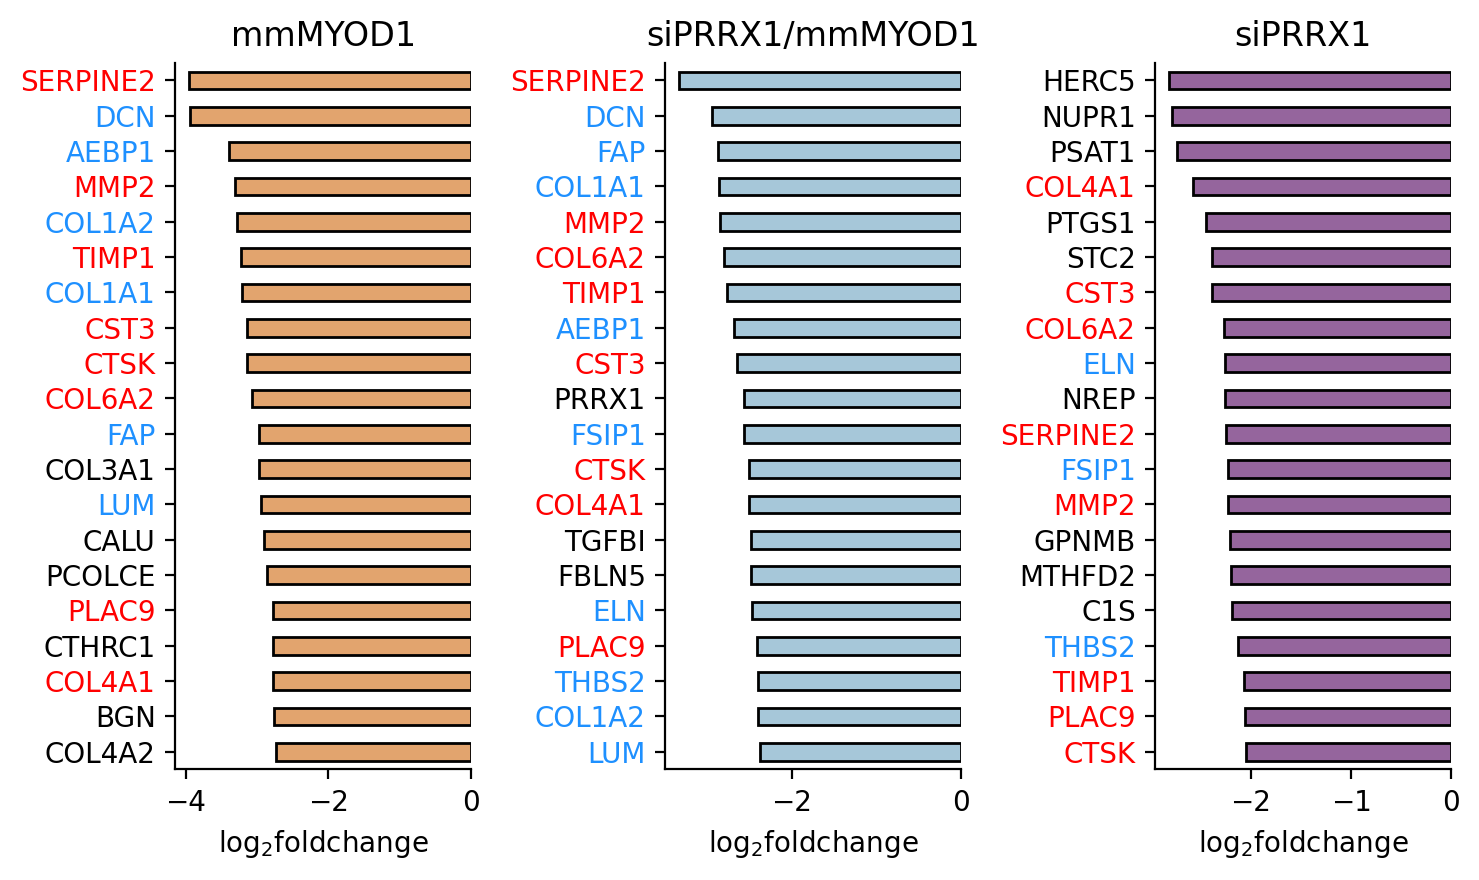

In [20]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 7.5, 4.5

fig, axs = plt.subplots(nrows=1, ncols=3)

n_genes = 20


top_genes_per_group = {}

for group in plot_order:
    df = pdf[pdf['group'] == group].sort_values(by='logfoldchanges', ascending=True)
    top_genes_per_group[group] = df.head(n_genes)['names'].tolist()

# Step 2: Count appearances across groups
gene_counts = Counter()
for gene_list in top_genes_per_group.values():
    gene_counts.update(gene_list)

# Step 3: Categorize genes
red_genes = {gene for gene, count in gene_counts.items() if count == 3}
blue_genes = {gene for gene, count in gene_counts.items() if count == 2}

for i, group in enumerate(plot_order): 
    df = pdf[pdf['group'] == group].sort_values(by='logfoldchanges', ascending=True).head(n_genes)
    ax = axs[i]

    sns.barplot(data=df, x='logfoldchanges', y='names', ax=ax, width=0.5, color=color_map[group], ec='k')
    ax.set_title(group)
    ax.set_xlabel("log$_2$foldchange")
    ax.set_ylabel("")


    for tick in ax.get_yticklabels():
        gene = tick.get_text()
        if gene in red_genes:
            tick.set_color('red')
            # tick.set_fontweight('semibold')
        elif gene in blue_genes:
            tick.set_color('dodgerblue')
            # tick.set_fontweight('semibold')

sns.despine()
plt.tight_layout()
plt.show()

In [8]:
group = 'mmMYOD1'

df = pdf[pdf['group'] == group]

print(f"N upregulated genes for {group}: {df[df['logfoldchanges'] > 0]['names'].nunique()}")
print(f"N downregulated genes for {group}: {df[df['logfoldchanges'] < 0]['names'].nunique()}")

df.head()

N upregulated genes for mmMYOD1: 4550
N downregulated genes for mmMYOD1: 1734


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,abs_lfc,gene_type,mt,ribo
0,mmMYOD1,MYOD1,69.678673,32.184513,0.0,0.0,1.000000,32.184513,protein_coding,False,False
3,mmMYOD1,NAV3,58.639927,3.446840,0.0,0.0,0.924609,3.446840,protein_coding,False,False
4,mmMYOD1,TAF1D,55.636890,2.705306,0.0,0.0,0.960645,2.705306,protein_coding,False,False
5,mmMYOD1,KCNQ5,54.305904,2.960109,0.0,0.0,0.952584,2.960109,protein_coding,False,False
6,mmMYOD1,IFIT3,52.313427,1.631886,0.0,0.0,0.984353,1.631886,protein_coding,False,False
